# Introduction to Parareal with time-dependent ODE

## Problem of interest

Consider the non-homogeneous Dahlquist problem :

$$
\frac{du}{dt} = \lambda u + \sin(\alpha t), \quad u(t_0) = u_0, \quad t \in [t_0, t_1],
$$

where $\lambda \in \mathbb{C}$ is usually a complex number and $\alpha$ is the frequency of the forcing term.
Under the condition that $\lambda^2 + \alpha^2 \neq 0$ (resonance regime), then the analytical solution of this ordinary differential equation is :

$$
u_{th}(t) = C e^{\lambda t} - \frac{\alpha \cos(\alpha t) + \lambda \sin(\alpha t)}{\alpha^2 + \lambda^2},
$$
where the constant $C$ depends on the initial solution $u_0$:
$$
C = e^{-\lambda t_0}\left[u_0 + \frac{\alpha \cos(\alpha t_0) + \lambda \sin(\alpha t_0)}{\alpha^2 + \lambda^2}\right]
$$

Considering the parameter values $\lambda=1j$ and $\alpha=6$, this corresponds to a solution that oscillates with a period of $2\pi$, with additional oscillations within each period induced by the time-dependent forcing term $\sin(\alpha t)$.
For instance taking $u_0 = 1$, we can plot the solution in the complex plane like this :

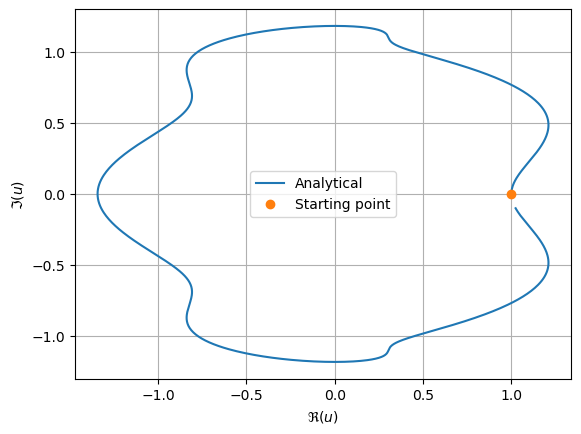

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1j
alpha = 6

def analytical(u0, t0, t1, nSteps):
    assert lam**2 + alpha**2 != 0, "resonance regime, different analytical solution"
    t = np.linspace(t0, t1, nSteps+1)
    C = np.exp(-lam*t0)*(u0 + (alpha*np.cos(alpha*t0) + lam*np.sin(alpha*t0))/(alpha**2 + lam**2))
    u = C*np.exp(lam*t) - (alpha*np.cos(alpha*t) + lam*np.sin(alpha*t))/(alpha**2 + lam**2)
    return t, u


nSteps = 1000
tEnd = 2*np.pi - 0.1    # small offset to see where the period starts and finishes
t, uTh = analytical(1, 0, tEnd, nSteps)

plt.plot(uTh.real, uTh.imag, label="Analytical")
plt.plot(uTh[0].real, uTh[0].imag, "o", label="Starting point")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

Solution starts at $u_0=1 + 0j$ then has a trajectory going around the origin $0 + 0j$ that comes back to the starting point after $t=2\pi$.
We can also represent it by plotting the real and imaginary parts of $u$ over time : 

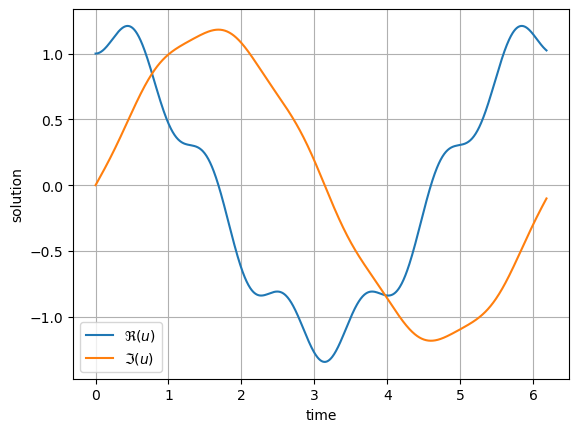

In [2]:
plt.plot(t, uTh.real, label="$\Re(u)$")
plt.plot(t, uTh.imag, label="$\Im(u)$")
plt.legend(), plt.xlabel("time"), plt.ylabel("solution"), plt.grid();

Now, let's try to solve this equation numerically, the same way we would solve a more complex problem to which we cannot compute the analytical solution.
To avoid any numerical stability issue, we can start with the Backward Euler method that compute the solution of a general ODE
$$
\frac{du}{dt} = f(u,t),
$$
on one time-step $u_{i} -\rightarrow u_{i+1}$ using the discrete form of the ODE :
$$
\frac{u_{i+1} - u_{i}}{\Delta t} = f(u_{i+1}, t_{i+1}), \quad \Delta t = t_{i+1} - t_{i}.
$$
In practice, this implies that we have to solve the following equation :
$$
u_{i+1} - \Delta t f(u_{i+1}, t_{i+1}) = u_{i}
$$
where $u_{i}$, $f$ and $t_{i+1}$ are known, and $u_{i+1}$ is the unknown.
In our case (non-homogeneous Dahlquist), $f(u,t) = \lambda u + \sin(\alpha t)$ has a simpler form, so we can write it directly as :
$$
u_{i+1} - \Delta t (\lambda u_{i+1} + \sin(\alpha t_{i+1})) = u_{i} \Rightarrow u_{i+1} = \frac{u_{i} + \Delta t \sin(\alpha t_{i+1})}{1 - \Delta t \lambda},
$$
which can be explicitly computed.
Then, since we usually need to compute several time-step for the full simulation time-interval $[t_0, t_1]$, we can define the time-stepper function that solves the ODE numerically with `nSteps` time-steps like this :

In [3]:
def timeStepper(u0, t0, t1, nSteps):
    dt = (t1-t0)/nSteps
    t = np.linspace(t0, t1, nSteps+1)
    u = lam * np.zeros_like(t)

    u[0] = u0
    for i in range(nSteps):
        u[i+1] = (u[i] + dt*np.sin(alpha*t[i+1]))/(1-dt*lam)

    return t, u

Computing for instance with `nSteps=1000` and comparing with the analytical solution gives : 

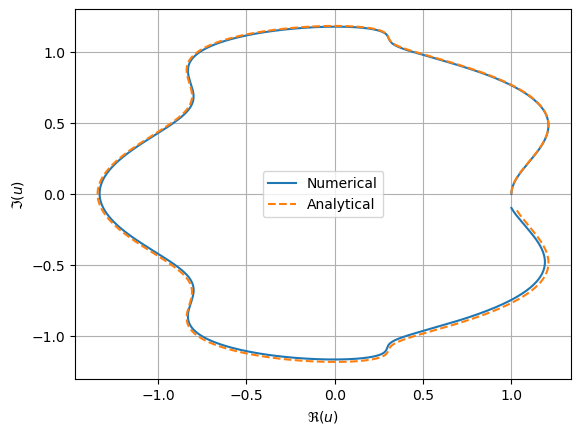

In [4]:
nSteps = 1000
# tEnd is already defined above ...
t, uNum = timeStepper(1, 0, tEnd, nSteps)

plt.plot(uNum.real, uNum.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

$\Rightarrow$ we observe a small discrepancy between numerical and analytical solution, due to the discretization error of Backward Euler.
This can be reduced by computing on more time-steps, like ten times more :

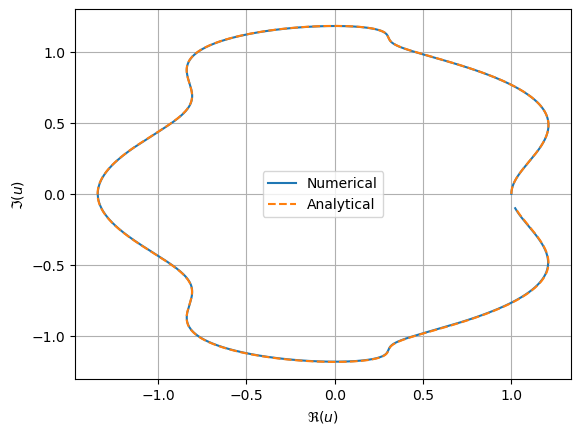

In [5]:
nSteps = 10000
# tEnd is already defined above ...
t, uNum = timeStepper(1, 0, tEnd, nSteps)

plt.plot(uNum.real, uNum.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

Usually, it's interesting to look at the evolution of the error w.r.t the number of time-steps, for instance like this (with log-log plots):

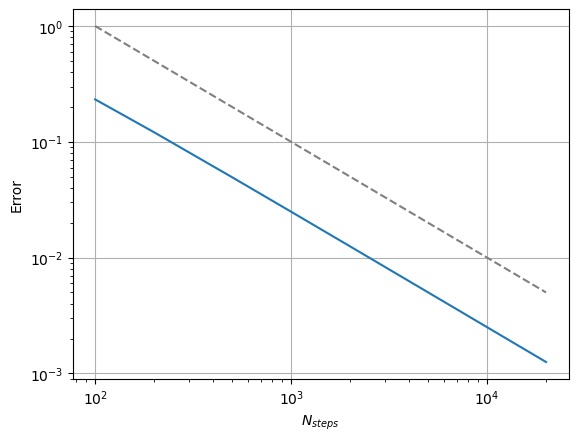

In [6]:
nStepsVals = np.array([100, 200, 500, 1000, 2000, 5000, 10000, 20000])

errors = []
for nSteps in nStepsVals:
    _, uTh = analytical(1, 0, tEnd, nSteps)
    _, uNum = timeStepper(1, 0, tEnd, nSteps)
    errors.append(np.linalg.norm(uNum-uTh, ord=np.inf))     # use the L_infty norm to get the maximum absolute value difference 

plt.loglog(nStepsVals, errors)
plt.loglog(nStepsVals, 1e2/nStepsVals, "--", c="gray")
plt.xlabel("$N_{steps}$"), plt.ylabel("Error"), plt.grid();

$\Rightarrow$ we can see that the log of the error decrease linearly with the log of $N_{steps}$, which is characteristic from the first order accuracy of the Backward Euler time integration and assert that we implemented it correctly.

## Standard Parareal

You can use the base implementation of Parareal provided [here](https://github.com/Parallel-in-Time/book-pint-code/blob/gaia/chap2/sec2.3/Parareal.py), and generally the application examples provided [here](https://github.com/Parallel-in-Time/book-pint-code/blob/gaia/chap2/README.md#section-23--the-parareal-algorithm).

> 💡 What is called "coarse time-points" with Parareal are the interfaces of each time-windows. 
 
Use it on the Dahlquist problem defined above, considering $N=10$ time-windows, a fine solver $\mathcal{F}$ that uses $N_{steps,F}$ time-steps per period to compute solution, and a coarse solver $\mathcal{G}$ that uses $N_{steps,G} < N_{steps,F}$ time-steps per period.
We denote by **Parareal error** the one between the Parareal solution and the sequential solution (computed without Parareal).
First, look at :

- maximum Parareal error for all coarse points VS iteration number 
- Parareal error VS time for different iterations number

$\Rightarrow$ you should see the "systematic" convergence of Parareal that assess that it's correctly implemented.

Then, there is a small optimization problem to find the "optimal" Parareal configuration :

1. you know the discretization error of the fine sequential solution (thanks to the comparison with analytical solution) : $e_{discr}$
2. you can estimate the cost of your fine solver by counting the number of stages that has to be done in parallel, i.e :
$$
C_{seq} = N N_{steps,F}
$$
3. you can estimate the cost of Parareal in function of the number of iterations $K$ and the number of time-steps $N_{steps,G}$ for the coarse solver using the distributed implementation of Parareal from [Aubanel](https://doi.org/10.1016/j.parco.2010.10.004) :
$$
C_{Parareal} = N N_{steps,G} + K(N_{steps,F} + N_{steps,G})
$$ 
4. you can retrieve from it the parallel speedup of Parareal :
$$
S = \frac{C_{seq}}{C_{Parareal}} = \frac{N}{Nr + K(1+r)}, \quad r := \frac{N_{steps,G}}{N_{steps,F}}
$$
5. for one given $N_{steps,G}$, you can compute how much iterations $K$ are needed to put the error of Parareal below $e_{discr}$

$\Rightarrow$ which value $N_{steps,G}$ maximizes the speedup of Parareal given enough iteration are done to ensure point n°5 ?

## Adaptive Parareal

Before going to a battery model, we can consider the modified non-homogeneous Dahlquist problem :

$$
\frac{du}{dt} = \lambda(t) u + \sin(\alpha t), \quad u(t_0) = u_0, \quad t \in [t_0, t_1],
$$

where $\lambda(t) = 1j(1+\epsilon(t))$ and $\epsilon(t)$ a small variation that varies after one period (i.e when $\Im(u)$ reaches 0 for the second time).
Since the period is $T=2\pi\lambda(t)$, this will emulate a pseudo-periodic problem and the idea is to implement the Parareal algorithm such that is works on this.

> First, we can consider a step function for $\epsilon(t) = 0.01 n$ where $n$ is the index of the time-windows.